In [36]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
url = "http://www.stat.cmu.edu/~larry/=stat401/abalone.csv"

resp = requests.get(url, verify=False)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))
df.to_csv("abalone.csv", index=False)

print(df.head())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.stat.cmu.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


   Height  Rings
0   0.095     15
1   0.090      7
2   0.135      9
3   0.125     10
4   0.080      7


In [3]:
X = df["Height"]
y = df["Rings"]

# Exploratory Data Analysis

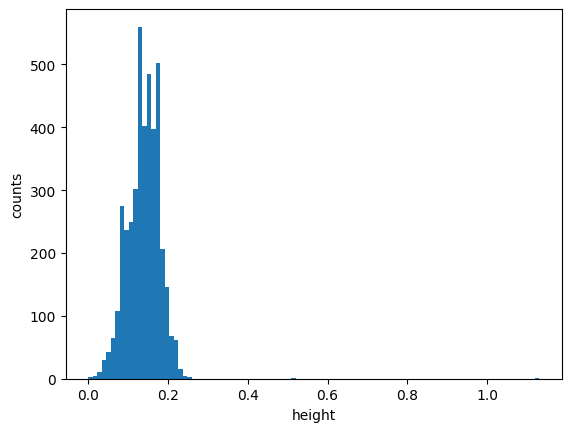

In [29]:
plt.hist(X, bins=100)
plt.xlabel("height")
plt.ylabel("counts")
plt.show()

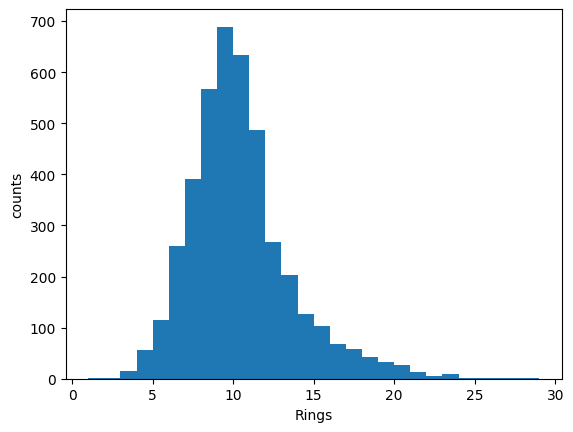

In [27]:
_, bins, _ = plt.hist(y, bins=28)
# print(bins)
plt.xlabel("Rings")
plt.ylabel("counts")
plt.show()

In [30]:
desc = df.describe()
desc.loc["num_NaNs"] = df.isna().sum()
desc

,Height,Rings
count,4177.000000,4177.000000
mean,0.139516,9.933684
std,0.041827,3.224169
min,0.000000,1.000000
25%,0.115000,8.000000
50%,0.140000,9.000000
75%,0.165000,11.000000
max,1.130000,29.000000
num_NaNs,0.000000,0.000000


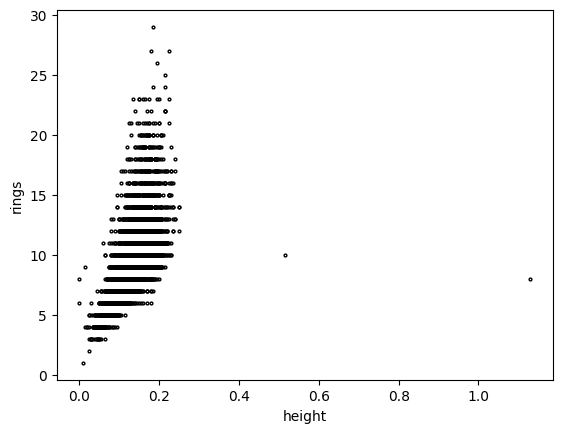

In [35]:
plt.plot(X, y, 'o', markersize=2, fillstyle='none', color='black')
plt.xlabel("height")
plt.ylabel("rings")
plt.show()

# Fitting a simple linear regression

In [38]:
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     1882.
Date:                Sat, 14 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:13:46   Log-Likelihood:                -10039.
No. Observations:                4177   AIC:                         2.008e+04
Df Residuals:                    4175   BIC:                         2.009e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9385      0.144     27.302      0.0

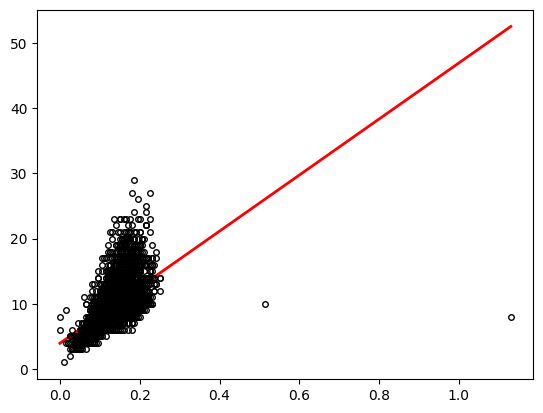

In [41]:
X_vals = np.linspace(X.min(), X.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X, y, 'o', markersize=4, fillstyle='none', color='black')

# Model Diagnostics

Residuals vs Fitted Values plot

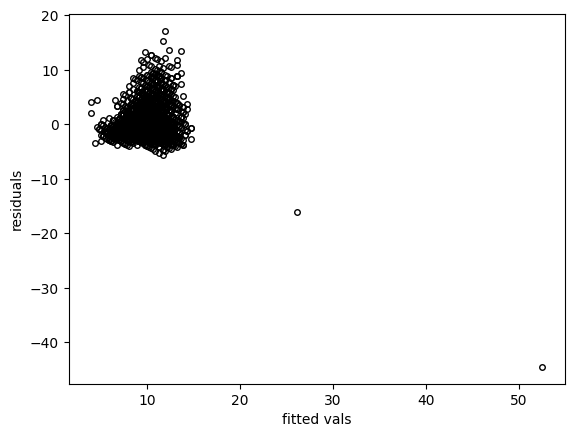

In [46]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.plot(fitted_vals, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("fitted vals")
plt.ylabel("residuals")
plt.show()

Either heteroskedastic or linear assumption violated, more likely linear regression assumption is violated

In [61]:
df_ = df[df["Height"] <= 0.4]

print(df_.sort_values(by='Height'))

df_clean = df_.drop(index=[3996, 1257, 1174, 2169]) # remove the outliers

X_clean = df_clean["Height"]
y_clean = df_clean["Rings"]

      Height  Rings
3996   0.000      6
1257   0.000      8
236    0.010      1
1174   0.015      9
2169   0.015      4
...      ...    ...
1528   0.240     13
2161   0.240     17
1428   0.250     14
1763   0.250     12
2179   0.250     14

[4175 rows x 2 columns]


                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     2474.
Date:                Sat, 14 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:06:58   Log-Likelihood:                -9829.4
No. Observations:                4171   AIC:                         1.966e+04
Df Residuals:                    4169   BIC:                         1.968e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7782      0.149     18.612      0.0

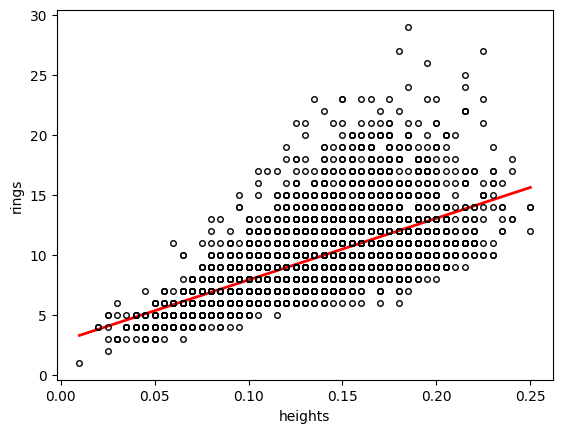

In [62]:
X_clean_sm = sm.add_constant(X_clean)
model_clean = sm.OLS(y_clean, X_clean_sm).fit()
print(model_clean.summary())

X_vals = np.linspace(X_clean.min(), X_clean.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model_clean.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X_clean, y_clean, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("heights")
plt.ylabel("rings")
plt.show()

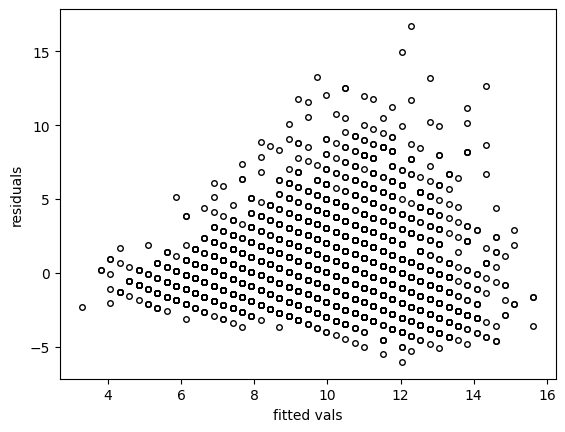

In [63]:
fitted_vals = model_clean.fittedvalues
residuals = model_clean.resid

plt.plot(fitted_vals, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("fitted vals")
plt.ylabel("residuals")
plt.show()

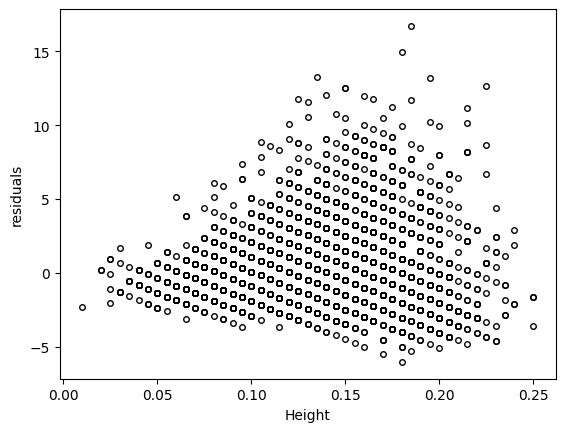

In [64]:
residuals = model_clean.resid

plt.plot(X_clean, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("Height")
plt.ylabel("residuals")
plt.show()

Looks a lot like heteroscedasticity

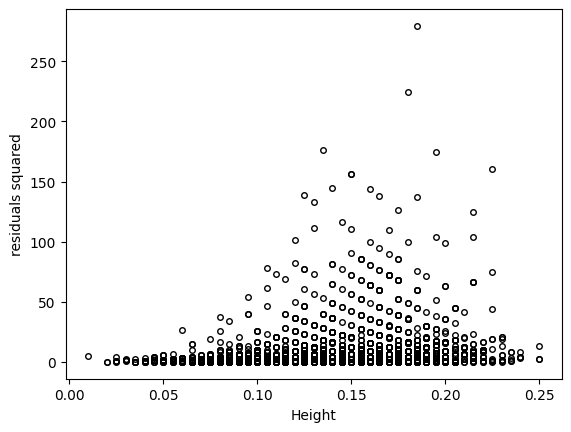

In [65]:
residuals = model_clean.resid

plt.plot(X_clean, residuals ** 2, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("Height")
plt.ylabel("residuals squared")
plt.show()

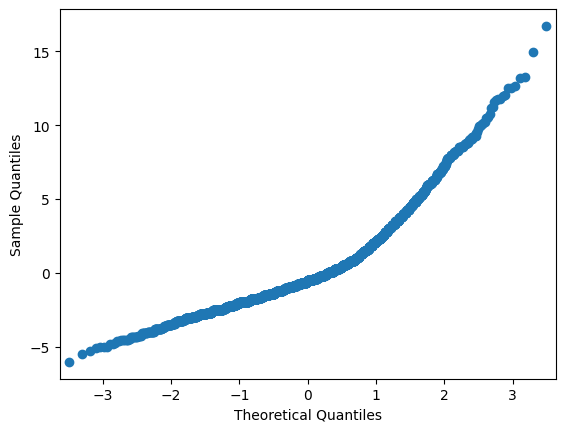

In [66]:
sm.qqplot(residuals)
plt.show()

-0.28


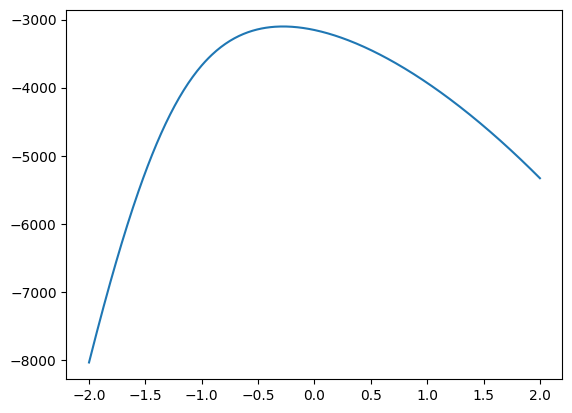

In [74]:
def boxcox(lambd, y, X):
    if np.isclose(lambd, 0):
        y_bc = np.log(y)
    else:
        y_bc = (y**lambd - 1)/(lambd)
    
    X_bc = sm.add_constant(X)
    bxcx = sm.OLS(y_bc, X_bc).fit()
    
    rss = np.sum((bxcx.resid)**2)
    n = len(y)

    llf = -n/2 * np.log(rss/n) + (lambd - 1) * np.sum(np.log(y))

    return llf

Xlog = np.log(X_clean)

lambds = np.linspace(-2, 2, 401)
lls = [boxcox(lmd, y_clean, Xlog) for lmd in lambds]
lambd_hat = lambds[np.argmax(lls)]
print(lambd_hat)

plt.plot(lambds, lls)
plt.show()


In [84]:
# y_log = np.log(y_clean)
y_log = (y_clean ** lambd_hat - 1)/lambd_hat
X_log = np.log(X_clean)
X_log_sm = sm.add_constant(X_log)

model_bc = sm.OLS(y_log, X_log_sm).fit()
print(model_bc.summary())

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     4758.
Date:                Sun, 15 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:09:29   Log-Likelihood:                 2970.7
No. Observations:                4171   AIC:                            -5937.
Df Residuals:                    4169   BIC:                            -5925.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4509      0.012    210.935      0.0

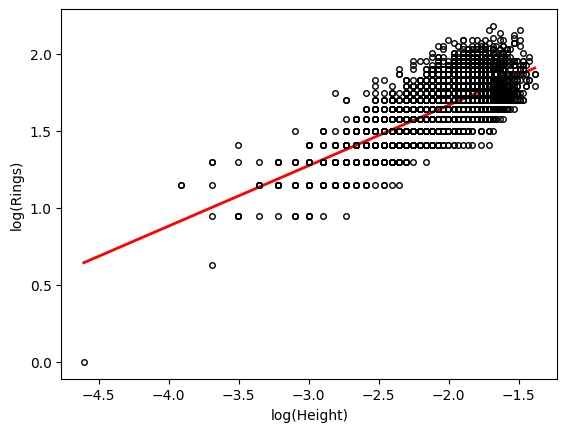

In [85]:
X_vals = np.linspace(X_log.min(), X_log.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model_bc.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")

plt.plot(X_log, y_log, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("log(Height)")
plt.ylabel("log(Rings)")
plt.show()

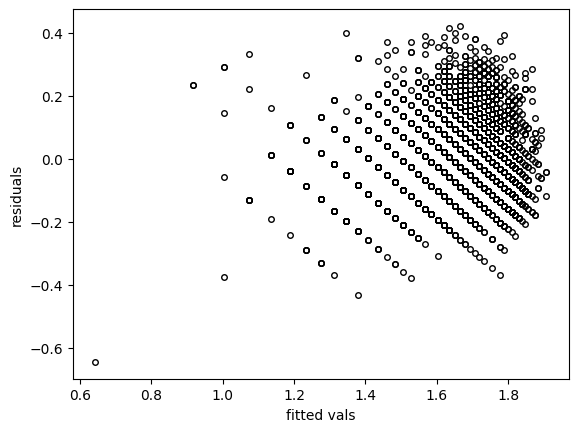

In [88]:
fitted_vals = model_bc.fittedvalues
residuals = model_bc.resid

plt.plot(fitted_vals, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("fitted vals")
plt.ylabel("residuals")
plt.show()

No matter what we try, there is inevitably some heteroscedasticity

In [91]:
clean_ci = model_clean.conf_int(alpha=0.05)
print(clean_ci)

                0          1
const    2.485584   3.070897
Height  49.360983  53.412141


In [93]:
pvals = model_clean.pvalues
print(pvals)

const     2.462760e-74
Height    0.000000e+00
dtype: float64


In [108]:
x_new = np.array([1, 0.128])
x_new_sm = sm.add_constant(x_new)

pred = model_clean.get_prediction(x_new_sm)

print(pred.summary_frame(alpha=0.05))

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  54.164802  0.890119      52.419694      55.909911     48.861028   
1   9.355720  0.041247       9.274854       9.436587      4.346613   

   obs_ci_upper  
0     59.468577  
1     14.364828  


In [109]:
x_new = np.array([1, 0.132])
x_new_sm = sm.add_constant(x_new)

pred = model_clean.get_prediction(x_new_sm)

print(pred.summary_frame(alpha=0.01))

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  54.164802  0.890119      51.870957      56.458648     47.193293   
1   9.561266  0.040271       9.457487       9.665046      2.977120   

   obs_ci_upper  
0     61.136312  
1     16.145413  
